## Darbą atliko Lukas Janušauskas ir Martynas Zabitis

# Bibliotekos, kurias reikės parsisiųsti, kad pasileistų, siūlome pasidaryti laikiną virtual environment:

In [ ]:
!! pip install torch==2.10.0 transformers==5.3.0 yfinance==1.2.0 numpy==2.4.2 pandas==3.0.1 PyPortfolioOpt==1.6.0

['Requirement already satisfied: torch==2.10.0 in ./venv/lib/python3.12/site-packages (2.10.0)',
 'Requirement already satisfied: transformers==5.3.0 in ./venv/lib/python3.12/site-packages (5.3.0)',
 'Requirement already satisfied: yfinance==1.2.0 in ./venv/lib/python3.12/site-packages (1.2.0)',
 'Requirement already satisfied: numpy==2.4.2 in ./venv/lib/python3.12/site-packages (2.4.2)',
 'Requirement already satisfied: pandas==3.0.1 in ./venv/lib/python3.12/site-packages (3.0.1)',
 'Requirement already satisfied: filelock in ./venv/lib/python3.12/site-packages (from torch==2.10.0) (3.25.2)',
 'Requirement already satisfied: typing-extensions>=4.10.0 in ./venv/lib/python3.12/site-packages (from torch==2.10.0) (4.15.0)',
 'Requirement already satisfied: setuptools in ./venv/lib/python3.12/site-packages (from torch==2.10.0) (82.0.0)',
 'Requirement already satisfied: sympy>=1.13.3 in ./venv/lib/python3.12/site-packages (from torch==2.10.0) (1.14.0)',
 'Requirement already satisfied: net

## Bibliotekų importavimas

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf

## Importuojame duomenis

In [3]:
tickers = ["BTC-USD", "GC=F", "BZ=F"]
df = yf.download(tickers, start="2014-01-01")

# Suvienodinti dazni, nes portfeli sudaro kripto ir derivatyvai
df = df.dropna()["Close"]

# Apskaiciuojame grazas
returns = df.pct_change().dropna()

[*********************100%***********************]  3 of 3 completed


In [4]:
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)


In [5]:
# 1 užduotis
def compute_rsi(price_series: pd.Series, window: int = 14) -> pd.Series:
    delta = price_series.diff()

    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(window=window, min_periods=window).mean()
    avg_loss = losses.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi



In [6]:
df['rsi-btc'] = compute_rsi( df['BTC-USD'] )
df['rsi-gold'] = compute_rsi( df['GC=F'] )
df['rsi-brent'] = compute_rsi( df['BZ=F'] )

In [7]:
df

Ticker,BTC-USD,BZ=F,GC=F,rsi-btc,rsi-gold,rsi-brent
Date,,,,,,
2014-09-17,457.334015,98.970001,1234.400024,NaN,NaN,NaN
2014-09-18,424.440002,97.699997,1225.699951,NaN,NaN,NaN
2014-09-19,394.795990,98.389999,1215.300049,NaN,NaN,NaN
2014-09-22,402.152008,96.970001,1216.800049,NaN,NaN,NaN
2014-09-23,435.790985,96.849998,1221.000000,NaN,NaN,NaN
...,...,...,...,...,...,...
2026-03-13,70968.265625,103.139999,5052.500000,64.638800,42.013019,78.457117
2026-03-16,74861.085938,100.209999,4994.000000,71.518810,41.593954,75.458325
2026-03-17,73922.476562,103.419998,5001.000000,63.484111,38.822398,76.718626


In [8]:
df['rsi-signal-btc'] = 0
df.loc[df['rsi-btc'] < 30, 'rsi-signal-btc'] = 1
df.loc[df['rsi-btc'] > 70, 'rsi-signal-btc'] = -1

df['rsi-signal-gold'] = 0
df.loc[df['rsi-gold'] < 30, 'rsi-signal-gold'] = 1
df.loc[df['rsi-gold'] > 70, 'rsi-signal-gold'] = -1

df['rsi-signal-brent'] = 0
df.loc[df['rsi-brent'] < 30, 'rsi-signal-brent'] = 1
df.loc[df['rsi-brent'] > 70, 'rsi-signal-brent'] = -1

In [9]:
df['btc-returns'] = df['BTC-USD'].pct_change()
df['gold-returns'] = df['GC=F'].pct_change()
df['brent-returns'] = df['BZ=F'].pct_change()

In [10]:
btc_svoris = 0.5
gold_svoris = 0.2
brent_svoris = 0.3

df['rsi-returns'] = (
    df['rsi-btc'].shift(1) * df['btc-returns'] * btc_svoris +
    df['rsi-gold'].shift(1) * df['gold-returns'] * gold_svoris +
    df['rsi-brent'].shift(1) * df['brent-returns'] * brent_svoris
)

In [11]:
fin_df = df.copy()

In [12]:
from IPython import display

sharpe_rsi = ( fin_df['rsi-returns'].mean() - 0.03 ) / fin_df['rsi-returns'].std() * np.sqrt(252)
display.Markdown(f"# RSI strategijos sharpe: {sharpe_rsi:.3f}")

# RSI strategijos sharpe: 1.005

# Importuojame duomenis snetimentų analizei

In [13]:
# read data\BTC_news_articles.csv
btc_news_df = pd.read_csv("data/BTC_news_articles.csv", sep=';')
btc_news_df = btc_news_df[["title", "newsDatetime"]]

btc_news_df.head()

,title,newsDatetime
0,"Bitcoin (BTC) Loses 200-Day MA, Tries to Hold ...",2021-08-18 09:50
1,Crypto Analyst Lark Davis on Bitcoin: ‘Still G...,2021-08-18 10:10
2,Where I am BUYING Bitcoin,2021-08-18 18:27
3,Twitter’s Jack Dorsey Is Now Mining Bitcoin. H...,2021-08-18 18:56
4,Bitcoin Trading Volume Sinks Without Decisive ...,2021-08-18 19:00


In [14]:
# read data\gold_1.xlsx
gold_news_df_1 = pd.read_excel("data/gold_1.xlsx")
gold_news_df_2 = pd.read_excel("data/gold_2.xlsx")
gold_news_df_3 = pd.read_excel("data/gold_3.xlsx")


In [15]:
gold_news_df_1 = gold_news_df_1.rename(
    columns={'Title':'title', 'Submitted Date':'date'}
)

gold_news_df_2 = gold_news_df_2.rename(
    columns={'title':'title', 'date':'date'}
)

gold_news_df_3 = gold_news_df_3.rename(
    columns={'Title':'title', 'Published Date':'date'}
)

for df in (gold_news_df_1, gold_news_df_2, gold_news_df_3):
    df['date'] = pd.to_datetime(df['date'], utc=True)

In [16]:
all_gold = pd.concat([gold_news_df_1, gold_news_df_2, gold_news_df_3],
                     ignore_index=True)

all_gold = all_gold.sort_values('date')[["title", "date"]]

In [17]:
all_gold

,title,date
0,Comex Gold Speculators 'Miss the Move' as Bull...,2013-10-02 00:00:00+00:00
1,Gold Price Hits $3000 as US Consumer Sentiment...,2016-03-07 00:00:00+00:00
2,"Gold Hits New Dollar Record, $25 Off $3000, as...",2016-10-07 00:00:00+00:00
3,$33 Silver Cuts Gold/Silver Ratio as US Stocks...,2016-11-09 00:00:00+00:00
4,"Gold Rises, Silver Spikes as Stocks Slump Agai...",2016-11-10 00:00:00+00:00
...,...,...
427,Trump's Spending & Inflation 'Look Positive' f...,2025-03-11 00:00:00+00:00
428,Gold Trading Hits Shanghai Record on Trump Vic...,2025-03-12 00:00:00+00:00
429,Gold Prices Regain 'Key' 200-Day Moving Averag...,2025-03-13 00:00:00+00:00
430,"Gold Prices Up 20% in 2016 on Euro NIRP, ETF D...",2025-03-14 00:00:00+00:00


In [18]:
# read data\oil_sentiment_headlines.csv
oil_news_df = pd.read_csv("data/oil_sentiment_headlines.csv")[["date", "headline"]]

oil_news_df

,date,headline
0,2019-01-03,$83.7 billion in Iraq &apos; s oil revenues in...
1,2019-01-10,Study: soda destroys kidneys.
2,2019-01-14,American official: We want Qatar to challenge ...
3,2019-01-15,"Stone decor in houses... happiness, warmth and..."
4,2019-01-15,From inside Haftar prisons... shocking account...
...,...,...
11063,2026-03-10,Iran Vows To Fight On After Trump Hints At Ear...
11064,2026-03-10,"US Dollar Is Still the Dominant Currency, Tema..."
11065,2026-03-10,Trump Signals Possible End to Iran War; Oil sl...
11066,2026-03-10,Today will be 'most intense day' of strikes on...


## Čia importuojame modelį, kurį naudosime. Kadangi dirbame su geopolitika susijusiais duomenimis, reikia modelio, kuris suprastų kontekstą, Vader yra paremtas taisyklėmis, taigi jis neturi jokio "išmokimo", pilno konteksto šis metodas nesupranta, todėl naudosime mašininiu mokymosi pagrįstą modelį: FinBERT

In [19]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline
import torch

# pip install --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

finbert_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=-1,
 )


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
def calculate_sentiment(row: pd.Series):
    if row['sentiment_label'] == 'negative':
        return -1 * row['sentiment_score']
    elif row['sentiment_label'] == 'positive':
        return row['sentiment_score']
    else:
        return 0

In [21]:
titles = btc_news_df["title"].fillna("").astype(str)

sentiment_labels = []
sentiment_scores = []

for title in titles:
    result = finbert_pipeline(title, truncation=True)[0]
    sentiment_labels.append(result["label"].lower())
    sentiment_scores.append(result["score"])

btc_news_df = btc_news_df.copy()
btc_news_df["sentiment_label"] = sentiment_labels
btc_news_df["sentiment_score"] = sentiment_scores

btc_news_df.head(10)

,title,newsDatetime,sentiment_label,sentiment_score
0,"Bitcoin (BTC) Loses 200-Day MA, Tries to Hold ...",2021-08-18 09:50,negative,0.750021
1,Crypto Analyst Lark Davis on Bitcoin: ‘Still G...,2021-08-18 10:10,neutral,0.605760
2,Where I am BUYING Bitcoin,2021-08-18 18:27,neutral,0.940171
3,Twitter’s Jack Dorsey Is Now Mining Bitcoin. H...,2021-08-18 18:56,neutral,0.943969
4,Bitcoin Trading Volume Sinks Without Decisive ...,2021-08-18 19:00,negative,0.958768
5,Bitcoin-first Compass Mining Accounts Shut Dow...,2021-08-19 00:15,negative,0.949127
6,JPMorgan Chase reportedly shuts down bank acco...,2021-08-19 10:46,negative,0.958980
7,Bitcoin slides with S&P 500 as Fed signals tap...,2021-08-19 11:32,negative,0.880537
8,BTC Struggles Below Critical 200MA as Global M...,2021-08-19 11:55,neutral,0.658571
9,"Altcoin Index Rises Thanks to ADA, SOL, LUNA a...",2021-08-20 08:30,positive,0.926643


In [37]:
btc_news_df['btc-sentiment'] = btc_news_df.apply(calculate_sentiment, axis='columns')

btc_news_df['day'] = pd.to_datetime(btc_news_df['newsDatetime']).dt.normalize()
btc_sentiment = btc_news_df\
    .groupby('day')\
    ['btc-sentiment']\
    .mean()\
    .to_frame()

In [39]:
fin_df = pd.merge( 
    btc_sentiment.reset_index(),
    fin_df.reset_index(),
    left_on='day',
    right_on='Date',
)\
    .drop(columns=['day'])\
    .set_index('Date')

In [25]:
titles = all_gold["title"].fillna("").astype(str)

sentiment_labels = []
sentiment_scores = []

for title in titles:
    result = finbert_pipeline(title, truncation=True)[0]
    sentiment_labels.append(result["label"].lower())
    sentiment_scores.append(result["score"])

all_gold = all_gold.copy()
all_gold["sentiment_label"] = sentiment_labels
all_gold["sentiment_score"] = sentiment_scores

all_gold.head(10)

,title,date,sentiment_label,sentiment_score
0,Comex Gold Speculators 'Miss the Move' as Bull...,2013-10-02 00:00:00+00:00,negative,0.875632
1,Gold Price Hits $3000 as US Consumer Sentiment...,2016-03-07 00:00:00+00:00,negative,0.942899
2,"Gold Hits New Dollar Record, $25 Off $3000, as...",2016-10-07 00:00:00+00:00,positive,0.614648
3,$33 Silver Cuts Gold/Silver Ratio as US Stocks...,2016-11-09 00:00:00+00:00,negative,0.790079
4,"Gold Rises, Silver Spikes as Stocks Slump Agai...",2016-11-10 00:00:00+00:00,negative,0.683250
5,Gold Hits 5-Week EUR and GBP Lows as Trump Tar...,2016-11-22 00:00:00+00:00,negative,0.874837
6,Gold and Silver Rebound as Comex-London Arb Wi...,2017-02-02 00:00:00+00:00,negative,0.937437
7,"Gold Down, Silver Firm as Trump Sends Copper 5...",2017-08-01 00:00:00+00:00,negative,0.660220
8,Germany's 'Debt Explosion' Knocks Gold 5% Off ...,2017-09-25 00:00:00+00:00,negative,0.946500
9,"Gold Hits Record CAD, MXN Prices as Trump's Ta...",2017-09-28 00:00:00+00:00,negative,0.863737


In [26]:
all_gold['gold-sentiment'] = all_gold.apply(calculate_sentiment, axis='columns')

all_gold['day'] = pd.to_datetime(all_gold['date']).dt.normalize()
all_gold = all_gold\
    .groupby('day')\
    ['gold-sentiment']\
    .mean()\
    .to_frame()

all_gold.index = all_gold.index.tz_localize(None).normalize()

In [27]:
fin_df = pd.merge( 
    all_gold.reset_index(),
    fin_df.reset_index(),
    left_on='day',
    right_on='Date',
)\
    .drop(columns=['day'])\
    .set_index('Date')

In [28]:
titles = oil_news_df["headline"].fillna("").astype(str)

sentiment_labels = []
sentiment_scores = []

for title in titles:
    result = finbert_pipeline(title, truncation=True)[0]
    sentiment_labels.append(result["label"].lower())
    sentiment_scores.append(result["score"])

oil_news_df = oil_news_df.copy()
oil_news_df["sentiment_label"] = sentiment_labels
oil_news_df["sentiment_score"] = sentiment_scores

oil_news_df.head(10)

,date,headline,sentiment_label,sentiment_score
0,2019-01-03,$83.7 billion in Iraq &apos; s oil revenues in...,neutral,0.914154
1,2019-01-10,Study: soda destroys kidneys.,neutral,0.879167
2,2019-01-14,American official: We want Qatar to challenge ...,positive,0.845280
3,2019-01-15,"Stone decor in houses... happiness, warmth and...",neutral,0.895805
4,2019-01-15,From inside Haftar prisons... shocking account...,negative,0.787668
5,2019-01-19,Be in Haftar prisons... certificates from the ...,neutral,0.937080
6,2019-01-19,"Because of fuel robbers, an explosion kills do...",negative,0.926140
7,2019-01-21,"After the resumption of a pump from Egypt, doe...",neutral,0.875634
8,2019-01-22,Using dogs and gas... attacking Palestinian pr...,negative,0.626961
9,2019-01-22,"Because of Russia, do Ukraine's gas transmissi...",negative,0.726836


In [29]:
oil_news_df['oil-sentiment'] = oil_news_df.apply(calculate_sentiment, axis='columns')

oil_news_df['day'] = pd.to_datetime(oil_news_df['date']).dt.normalize()
oil_news_df = oil_news_df\
    .groupby('day')\
    ['oil-sentiment']\
    .mean()\
    .to_frame()

oil_news_df.index = oil_news_df.index.tz_localize(None).normalize()

In [30]:
fin_df = pd.merge( 
    oil_news_df.reset_index(),
    fin_df.reset_index(),
    left_on='day',
    right_on='Date',
)\
    .drop(columns=['day'])\
    .set_index('Date')

## Agreguojame  signalą iš sentimentų analizės signalų

In [53]:
def sentiment_signals_get_sharpe(df_fin: pd.DataFrame, a: float):
    btc_svoris = 0.5
    gold_svoris = 0.2
    brent_svoris = 0.3

    fin_df['btc-sentiment-signal'] = 0
    fin_df.loc[fin_df['btc-sentiment'] < -1 * a, 'btc-sentiment-signal'] = -1
    fin_df.loc[fin_df['btc-sentiment'] > a, 'btc-sentiment-signal'] = 1

    fin_df['gold-sentiment-signal'] = 0
    fin_df.loc[fin_df['gold-sentiment'] < -1 * a, 'gold-sentiment-signal'] = -1
    fin_df.loc[fin_df['gold-sentiment'] > a, 'gold-sentiment-signal'] = 1

    fin_df['brent-sentiment-signal'] = 0
    fin_df.loc[fin_df['brent-sentiment'] < -1 * a, 'brent-sentiment-signal'] = -1
    fin_df.loc[fin_df['brent-sentiment'] > a, 'brent-sentiment-signal'] = 1

    sentiment_returns = (
        df_fin['btc-sentiment-signal'].shift(1) * df_fin['btc-returns'] * btc_svoris +
        df_fin['gold-sentiment-signal'].shift(1) * df_fin['gold-returns'] * gold_svoris +
        df_fin['brent-sentiment-signal'].shift(1) * df_fin['brent-returns'] * brent_svoris
    )

    return (sentiment_returns.mean() - 0.03) / sentiment_returns.std()

In [54]:
thresh = [0.1, 0.2, 0.5, 0.9]
sharpe = [ sentiment_signals_get_sharpe(fin_df, a) for a in thresh ]
best_sharpe = max(sharpe)
best_thresh = thresh[ np.argmax(sharpe) ]

print(best_sharpe, best_thresh)

-2.04110492159103 0.1


In [55]:
def combined_signals_get_sharpe(df_fin: pd.DataFrame, a: float):
    btc_svoris = 0.5
    gold_svoris = 0.2
    brent_svoris = 0.3

    fin_df['btc-sentiment-signal'] = 0
    fin_df.loc[fin_df['btc-sentiment'] < -1 * a, 'btc-sentiment-signal'] = -1
    fin_df.loc[fin_df['btc-sentiment'] > a, 'btc-sentiment-signal'] = 1

    fin_df['gold-sentiment-signal'] = 0
    fin_df.loc[fin_df['gold-sentiment'] < -1 * a, 'gold-sentiment-signal'] = -1
    fin_df.loc[fin_df['gold-sentiment'] > a, 'gold-sentiment-signal'] = 1

    fin_df['brent-sentiment-signal'] = 0
    fin_df.loc[fin_df['brent-sentiment'] < -1 * a, 'brent-sentiment-signal'] = -1
    fin_df.loc[fin_df['brent-sentiment'] > a, 'brent-sentiment-signal'] = 1

    fin_df['combined-btc'] = 0
    fin_df.loc[(fin_df['btc-sentiment-signal'] == 1) & (fin_df['rsi-btc'] < 30), 'combined-btc'] = 1
    fin_df.loc[(fin_df['btc-sentiment-signal'] == -1) & (fin_df['rsi-btc'] > 70), 'combined-btc'] = -1

    fin_df['combined-gold'] = 0
    fin_df.loc[(fin_df['gold-sentiment-signal'] == 1) & (fin_df['rsi-gold'] < 30), 'combined-gold'] = 1
    fin_df.loc[(fin_df['gold-sentiment-signal'] == -1) & (fin_df['rsi-gold'] > 70), 'combined-gold'] = -1

    fin_df['combined-oil'] = 0
    fin_df.loc[(fin_df['brent-sentiment-signal'] == 1) & (fin_df['rsi-brent'] < 30), 'combined-oil'] = 1
    fin_df.loc[(fin_df['brent-sentiment-signal'] == -1) & (fin_df['rsi-brent'] > 70), 'combined-oil'] = -1

    sentiment_returns = (
        df_fin['combined-btc'].shift(1) * df_fin['btc-returns'] * btc_svoris +
        df_fin['combined-gold'].shift(1) * df_fin['gold-returns'] * gold_svoris +
        df_fin['combined-oil'].shift(1) * df_fin['brent-returns'] * brent_svoris
    )

    return (sentiment_returns.mean() - 0.03) / sentiment_returns.std()

In [56]:
thresh = [0.1, 0.2, 0.5, 0.9]
sharpe = [ combined_signals_get_sharpe(fin_df, a) for a in thresh ]
best_sharpe = max(sharpe)
best_thresh = thresh[ np.argmax(sharpe) ]

print(best_sharpe, best_thresh)

-6.1144672908128905 0.1


In [58]:
a = 0.1

fin_df['btc-sentiment-signal'] = 0
fin_df.loc[fin_df['btc-sentiment'] < -1 * a, 'btc-sentiment-signal'] = -1
fin_df.loc[fin_df['btc-sentiment'] > a, 'btc-sentiment-signal'] = 1

fin_df['gold-sentiment-signal'] = 0
fin_df.loc[fin_df['gold-sentiment'] < -1 * a, 'gold-sentiment-signal'] = -1
fin_df.loc[fin_df['gold-sentiment'] > a, 'gold-sentiment-signal'] = 1

fin_df['brent-sentiment-signal'] = 0
fin_df.loc[fin_df['brent-sentiment'] < -1 * a, 'brent-sentiment-signal'] = -1
fin_df.loc[fin_df['brent-sentiment'] > a, 'brent-sentiment-signal'] = 1

fin_df['combined-btc'] = 0
fin_df.loc[(fin_df['btc-sentiment-signal'] == 1) & (fin_df['rsi-btc'] < 30), 'combined-btc'] = 1
fin_df.loc[(fin_df['btc-sentiment-signal'] == -1) & (fin_df['rsi-btc'] > 70), 'combined-btc'] = -1

fin_df['combined-gold'] = 0
fin_df.loc[(fin_df['gold-sentiment-signal'] == 1) & (fin_df['rsi-gold'] < 30), 'combined-gold'] = 1
fin_df.loc[(fin_df['gold-sentiment-signal'] == -1) & (fin_df['rsi-gold'] > 70), 'combined-gold'] = -1

fin_df['combined-oil'] = 0
fin_df.loc[(fin_df['brent-sentiment-signal'] == 1) & (fin_df['rsi-brent'] < 30), 'combined-oil'] = 1
fin_df.loc[(fin_df['brent-sentiment-signal'] == -1) & (fin_df['rsi-brent'] > 70), 'combined-oil'] = -1

fin_df['returns_sentiment'] = (
    fin_df['btc-sentiment-signal'].shift(1) * fin_df['btc-returns'] * btc_svoris +
    fin_df['gold-sentiment-signal'].shift(1) * fin_df['gold-returns'] * gold_svoris +
    fin_df['brent-sentiment-signal'].shift(1) * fin_df['brent-returns'] * brent_svoris
)

fin_df['returns_combined'] = (
    fin_df['combined-btc'].shift(1) * fin_df['btc-returns'] * btc_svoris +
    fin_df['combined-gold'].shift(1) * fin_df['gold-returns'] * gold_svoris +
    fin_df['combined-oil'].shift(1) * fin_df['brent-returns'] * brent_svoris
)

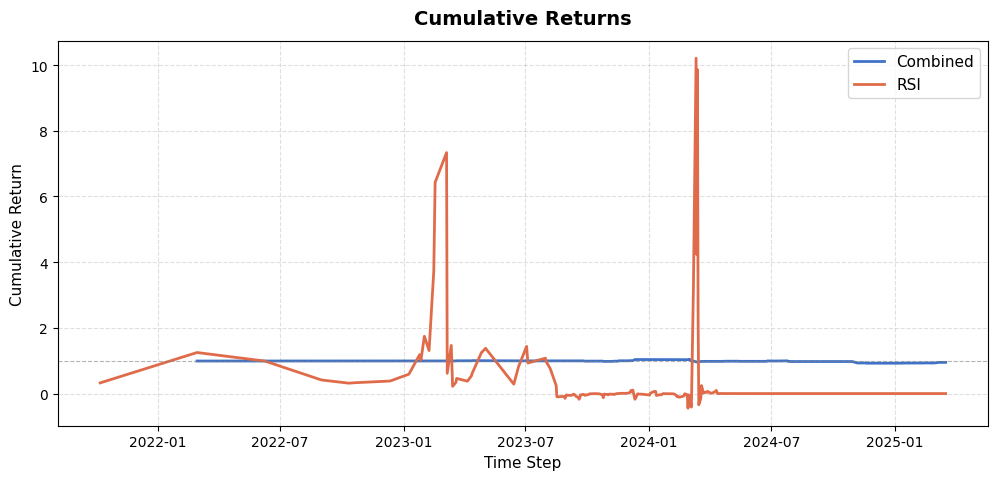

In [60]:
import matplotlib.pyplot as plt

cum_combined = (1 + fin_df['returns_combined']).cumprod()
cum_rsi = (1 + fin_df['rsi-returns']).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cum_combined.index, cum_combined, label='Combined', color='#3f72c8', linewidth=2)
ax.plot(cum_rsi.index, cum_rsi, label='RSI', color='#e06b4a', linewidth=2)

ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_title('Cumulative Returns', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Cumulative Return', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

In [ ]:
!! pip install 

['Collecting PyPortfolioOpt',
 '  Obtaining dependency information for PyPortfolioOpt from https://files.pythonhosted.org/packages/55/51/96055d65a76c5af14a12c3cf7c7232513c622b9a1159c42708de0fe85f98/pyportfolioopt-1.6.0-py3-none-any.whl.metadata',
 '  Downloading pyportfolioopt-1.6.0-py3-none-any.whl.metadata (23 kB)',
 'Collecting cvxpy>=1.1.19 (from PyPortfolioOpt)',
 '  Obtaining dependency information for cvxpy>=1.1.19 from https://files.pythonhosted.org/packages/b2/55/c6b5f0211deb58359b1a716216f6513fbd34c7fb9f5317c64fdc993cc998/cvxpy-1.8.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata',
 '  Downloading cvxpy-1.8.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (9.6 kB)',
 'Requirement already satisfied: numpy<3.0.0,>=1.26.0 in ./venv/lib/python3.12/site-packages (from PyPortfolioOpt) (2.4.2)',
 'Requirement already satisfied: pandas<4.0.0,>=1.0.0 in ./venv/lib/python3.12/site-packages (from PyPortfolioOpt) (3.0.1)',
 'Collecting scikit-b

In [76]:
from pypfopt import EfficientFrontier , risk_models , expected_returns

returns_df = fin_df[['returns_sentiment', 'rsi-returns']].dropna()

mu = expected_returns.mean_historical_return(returns_df, returns_data=True, frequency =252)
S = risk_models.sample_cov( returns_df, frequency =252)

ef = EfficientFrontier( mu , S )
weights = ef.min_volatility()

In [77]:
weights

OrderedDict([('returns_sentiment', 0.0641510561045801),
             ('rsi-returns', 0.93584894389542)])

In [83]:
returns_final = (fin_df['returns_sentiment'] * weights['returns_sentiment'] + fin_df['rsi-returns'] * weights['rsi-returns'])

(returns_final.mean() - 0.03) / returns_final.std() * np.sqrt(252)

np.float64(1.4645616242998793)

In [86]:
print( fin_df['rsi-returns'].std() / np.sqrt(252),
returns_final.std() / np.sqrt(252) )

0.06502917116245316 0.06089379231578766
